# Simple inference

In [49]:
import torch
import torch.nn.functional as F
from torchvision.transforms import v2
from PIL import Image
import matplotlib.pyplot as plt
import os
import sys
from models import build_model
import config as C

In [50]:
CHECKPOINT_PATH = "/home/framazan/stat-760/STAT-760-Final/checkpoints/simple_best.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [51]:
ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
model_name = ckpt.get("model_name", "advancedcnn")
print(f"Loading architecture: {model_name}")

model = build_model(model_name, pretrained=False)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()
print(f"Model loaded successfully.")

Loading architecture: simple
Model loaded successfully.


In [52]:
transform = v2.Compose([
    v2.Resize((C.IMAGE_SIZE, C.IMAGE_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=C.MEAN, std=C.STD)
])

def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    
    # Preprocess and add batch dimension
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1)[0]
    pred_idx = torch.argmax(probs).item()
    pred_class = C.CLASSES[pred_idx]
    confidence = probs[pred_idx].item()
    
    # Display
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    
    color = 'red' if pred_class == 'positive' else 'green'
    title = f"Prediction: {pred_class.upper()} ({confidence*100:.1f}%)"
    plt.title(title, color=color, fontsize=14, fontweight='bold')
    plt.show()
    
    print(f"Probabilities:\nNegative: {probs[0]:.4f}\nPositive: {probs[1]:.4f}")

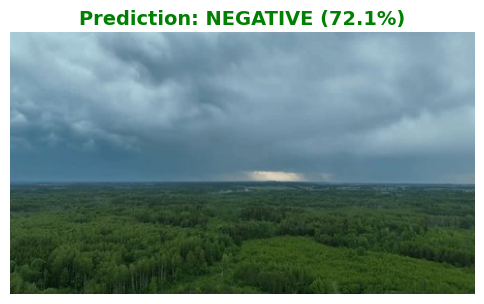

Probabilities:
Negative: 0.7215
Positive: 0.2785


In [53]:
IMAGE_PATH = "/home/framazan/stat-760/STAT-760-Final/test/1.jpg"
predict_image(IMAGE_PATH)